<a href="https://colab.research.google.com/github/hoiyaniharshita/Disease-Prediction-System/blob/main/DiseasePredictionSystem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

In [ ]:
# Step 2: Load dataset
df = pd.read_csv("/content/HeartDiseaseTrain-Test.csv")

# Display first 5 rows
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [ ]:
# Shape and info
print("Shape of dataset:", df.shape)
print("\nDataset Info:")
df.info()

# Check missing values
print("\nMissing values:\n", df.isnull().sum())

# Basic stats
df.describe()

Shape of dataset: (1025, 14)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thal

,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,target
count,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000
mean,54.434146,131.611707,246.00000,149.114146,1.071512,0.513171
std,9.072290,17.516718,51.59251,23.005724,1.175053,0.500070
min,29.000000,94.000000,126.00000,71.000000,0.000000,0.000000
25%,48.000000,120.000000,211.00000,132.000000,0.000000,0.000000
50%,56.000000,130.000000,240.00000,152.000000,0.800000,1.000000
75%,61.000000,140.000000,275.00000,166.000000,1.800000,1.000000
max,77.000000,200.000000,564.00000,202.000000,6.200000,1.000000


In [ ]:
# Fill missing values if any
df.fillna(df.mean(numeric_only=True), inplace=True)

# Encode categorical columns (if present)
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Display clean dataset
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,1,3,125,212,1,2,168,0,1.0,0,3,3,0
1,53,1,3,140,203,0,1,155,1,3.1,2,4,3,0
2,70,1,3,145,174,1,2,125,1,2.6,2,4,3,0
3,61,1,3,148,203,1,2,161,0,0.0,0,1,3,0
4,62,0,3,138,294,0,2,106,0,1.9,1,2,0,0


In [ ]:
# Assuming last column is the target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (820, 13)
Testing data: (205, 13)


In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test)

# Evaluation
print("🔹 Naive Bayes Model Results 🔹")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("Classification Report:\n", classification_report(y_test, y_pred_nb))

🔹 Naive Bayes Model Results 🔹
Accuracy: 0.775609756097561
Confusion Matrix:
 [[75 27]
 [19 84]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.74      0.77       102
           1       0.76      0.82      0.79       103

    accuracy                           0.78       205
   macro avg       0.78      0.78      0.78       205
weighted avg       0.78      0.78      0.78       205



In [ ]:
dt_model = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluation
print("🔹 Decision Tree Model Results 🔹")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

🔹 Decision Tree Model Results 🔹
Accuracy: 0.9707317073170731
Confusion Matrix:
 [[102   0]
 [  6  97]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97       102
           1       1.00      0.94      0.97       103

    accuracy                           0.97       205
   macro avg       0.97      0.97      0.97       205
weighted avg       0.97      0.97      0.97       205



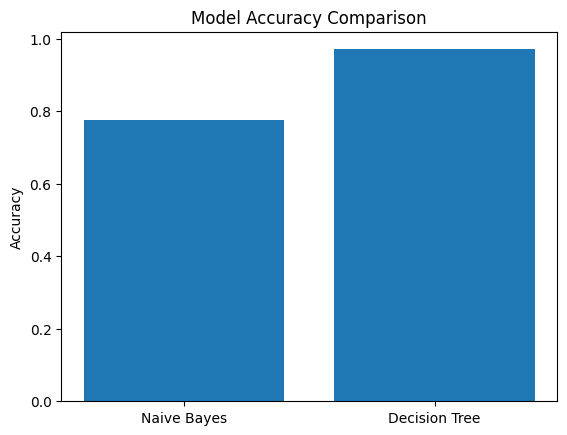

In [ ]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

models = ['Naive Bayes', 'Decision Tree']
accuracy = [accuracy_nb, accuracy_dt]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
with open('naive_bayes_model.pkl', 'wb') as f:
    pickle.dump(nb_model, f)

with open('decision_tree_model.pkl', 'wb') as f:
    pickle.dump(dt_model, f)

print("✅ Models saved successfully!")

✅ Models saved successfully!


In [ ]:
# Connect to database
conn = sqlite3.connect('disease_data.db')
cursor = conn.cursor()

# Create tables
cursor.execute('''CREATE TABLE IF NOT EXISTS patient_data (
    patient_id INTEGER PRIMARY KEY AUTOINCREMENT,
    age INTEGER,
    sex INTEGER,
    chest_pain_type INTEGER,
    blood_pressure INTEGER,
    cholesterol INTEGER,
    target INTEGER
)''')

# Insert data into patient_data table
df.to_sql('patient_data', conn, if_exists='replace', index=False)

conn.commit()
print("✅ Data successfully stored in SQLite database!")

✅ Data successfully stored in SQLite database!


In [ ]:
# Step 11: Run SQL Queries in Python (Colab-friendly)

# Reconnect to the same database
conn = sqlite3.connect('disease_data.db')
cursor = conn.cursor()

# 1️⃣ Show all tables
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("All tables:\n", tables, "\n")

# 2️⃣ View first 10 rows of patient data
sample_data = pd.read_sql_query("SELECT * FROM patient_data LIMIT 10;", conn)
print("First 10 records from patient_data table:")
display(sample_data)

# 3️⃣ Count total patients
count_patients = pd.read_sql_query("SELECT COUNT(*) as total_patients FROM patient_data;", conn)
print("Total number of patients:")
display(count_patients)

# 4️⃣ Count of disease vs non-disease
disease_count = pd.read_sql_query("SELECT target, COUNT(*) as count FROM patient_data GROUP BY target;", conn)
print("Disease vs Non-Disease Count:")
display(disease_count)

# 5️⃣ Average cholesterol by disease status
avg_chol = pd.read_sql_query("SELECT target, AVG(cholestoral) as avg_chol FROM patient_data GROUP BY target;", conn)
print("Average cholesterol grouped by disease status:")
display(avg_chol)

# Close connection
conn.close()

All tables:
               name
0  sqlite_sequence
1     patient_data 

First 10 records from patient_data table:


,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,1,3,125,212,1,2,168,0,1.0,0,3,3,0
1,53,1,3,140,203,0,1,155,1,3.1,2,4,3,0
2,70,1,3,145,174,1,2,125,1,2.6,2,4,3,0
3,61,1,3,148,203,1,2,161,0,0.0,0,1,3,0
4,62,0,3,138,294,0,2,106,0,1.9,1,2,0,0
5,58,0,3,100,248,1,1,122,0,1.0,1,4,0,1
6,58,1,3,114,318,1,0,140,0,4.4,2,2,2,0
7,55,1,3,160,289,1,1,145,1,0.8,1,1,3,0
8,46,1,3,120,249,1,1,144,0,0.8,0,4,3,0
9,54,1,3,122,286,1,1,116,1,3.2,1,3,0,0


Total number of patients:


,total_patients
0,1025


Disease vs Non-Disease Count:


,target,count
0,0,499
1,1,526


Average cholesterol grouped by disease status:


,target,avg_chol
0,0,251.292585
1,1,240.979087


In [ ]:
# Example new patient
# The model expects 13 features, in the same order as the training data (X_train)
# Replace the placeholder values with the actual data for your new patient
# The order of features is: age, sex, chest_pain_type, resting_blood_pressure, cholestoral, fasting_blood_sugar, rest_ecg, Max_heart_rate, exercise_induced_angina, oldpeak, slope, vessels_colored_by_flourosopy, thalassemia
new_patient = np.array([[52, 1, 0, 130, 250, 0, 1, 150, 0, 1.0, 0, 0, 0]])

# Naive Bayes prediction
nb_prediction = nb_model.predict(new_patient)[0]

# Decision Tree prediction
dt_prediction = dt_model.predict(new_patient)[0]

print("Naive Bayes Prediction:", nb_prediction)
print("Decision Tree Prediction:", dt_prediction)

Naive Bayes Prediction: 1
Decision Tree Prediction: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


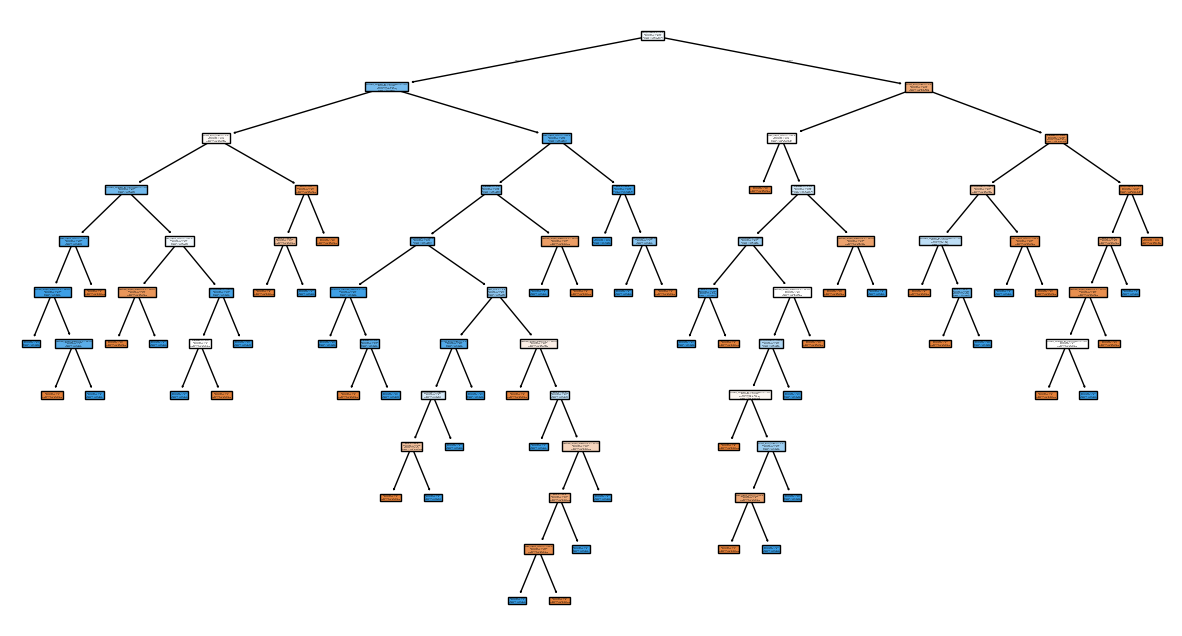

In [ ]:
plt.figure(figsize=(15, 8))
plot_tree(dt_model, filled=True, feature_names=X.columns, class_names=['No Disease', 'Disease'])
plt.show()

In [ ]:
conn.close()
print("🔚 Database connection closed.")

🔚 Database connection closed.
